In [ ]:
# New code to take data

import pandas as pd
import numpy as np
from dlisio import dlis  # Correct library import

def parse_dlis(file_path):
    all_data = {}

    with dlis.load(file_path) as files:
        for f in files:
            file_key = str(f)  # Unique identifier for each file

            file_data = {
                'frames': [
                    {
                        "frame_name": frame.name,
                        "channels": [
                            {
                                "curves_name": channel.name,
                                "long_name": channel.long_name,
                                "unit": channel.units,
                                "curves_data": np.array(channel.curves())  # Convert directly to numpy array
                            }
                            for channel in frame.channels
                        ]
                    }
                    for frame in f.frames
                ]
            }

            all_data[file_key] = file_data

    return all_data

# Example of calling the function
file_path = 'data/IODP_311-U1325A_rab-proc.dlis'
data = parse_dlis(file_path)


In [19]:
for logical_file in data:
    print(f'Logical file: {logical_file}')

Logical file: LogicalFile(RAB_shallow)
Logical file: LogicalFile(RAB_medium)
Logical file: LogicalFile(RAB_deep)


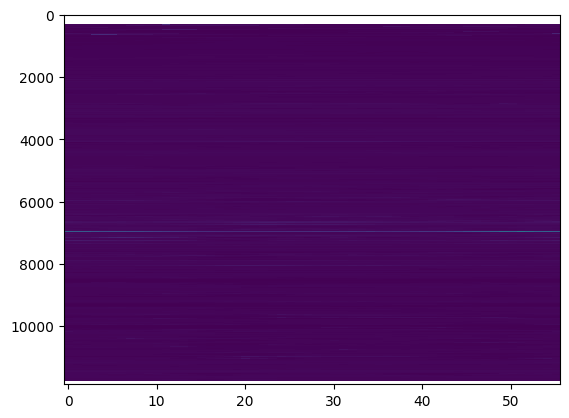

In [24]:
import matplotlib.pyplot as plt
# data access
# data['LogicalFile(RAB_shallow)']['frames'][0]['channels'][0]['curves_data']

a = data['LogicalFile(RAB_shallow)']['frames'][0]['channels'][1]['curves_data']
b = np.where(a == -999.25, np.nan, a)
plt.imshow(b, interpolation='nearest', aspect='auto')

In [5]:
data

{'LogicalFile(RAB_shallow)': {'frames': [{'frame_name': 'B77185',
    'channels': [{'curves_name': 'TDEP',
      'long_name': None,
      'unit': 'm',
      'curves_data': [np.float32(-3.26136),
       np.float32(-3.23088),
       np.float32(-3.2003999),
       np.float32(-3.16992),
       np.float32(-3.1394398),
       np.float32(-3.10896),
       np.float32(-3.07848),
       np.float32(-3.0479999),
       np.float32(-3.01752),
       np.float32(-2.98704),
       np.float32(-2.95656),
       np.float32(-2.92608),
       np.float32(-2.8955998),
       np.float32(-2.86512),
       np.float32(-2.83464),
       np.float32(-2.8041599),
       np.float32(-2.77368),
       np.float32(-2.7431998),
       np.float32(-2.71272),
       np.float32(-2.68224),
       np.float32(-2.6517599),
       np.float32(-2.62128),
       np.float32(-2.5908),
       np.float32(-2.56032),
       np.float32(-2.52984),
       np.float32(-2.4993598),
       np.float32(-2.46888),
       np.float32(-2.4384),
       n

In [ ]:
# Old visualization code

from dlisio import dlis
import numpy as np
import os
import pandas as pd

log = open('logs/LOG.txt', 'w')

#with dlis.load(r"D:\santos_from_bruna\1-BRSA-369A-RJS\Perfis\DLIS\Original\1-brsa-369a-rjs_raw2_8.dlis") as files: # 1-brsa-369a-rjs_raw2_8.dlis
with dlis.load('data/IODP_311-U1325A_rab-proc.dlis') as files:
    _m = {}
    for f in files:
        log.write(f'------------------------------------------------------------------ \n FILE: {f} \n ')
        #print(f'------------------------------------------------------------------ \n FILE: {f} \n ')
        for frame in f.frames:
                curves = frame.curves()
                
                channel_data = {
                        "curves_name": [],
                        "longs": [],
                        "unit": [],
                        "curves_L": [],
                        "curve_df": pd.DataFrame(),
                        "las_units": [],
                        "las_longs": [],
                    }
                
                for channel in frame.channels:
                    channel_data["curves_name"].append(channel.name)
                    channel_data["longs"].append(channel.long_name)
                    channel_data["unit"].append(channel.units)
                    curves = channel.curves()
                    channel_data["curves_L"].append(curves)
                #print(channel_data["curves_name"])
                #print(channel_data["curves_name"][0],":",channel_data["curves_L"][0][0],". . .",channel_data["curves_L"][0][1],'(',len(channel_data["curves_L"][0]),')')
                #print(channel_data["unit"])
                #print()
                for iii in range(len(channel_data["curves_name"])):
                    curve_dim = len(np.shape(channel_data["curves_L"][iii]))
                    top = "None"
                    bot = "None"
                    if curve_dim == 1:
                        top = channel_data["curves_L"][iii][0]
                        bot = channel_data["curves_L"][iii][1]
                    if curve_dim == 2:
                        top = channel_data["curves_L"][iii][0][0]
                        bot = channel_data["curves_L"][iii][-1][0]
                    if curve_dim == 3:
                        top = channel_data["curves_L"][iii][0][0][0]
                        bot = channel_data["curves_L"][iii][-1][0][0]
                    if curve_dim == 4:
                        top = channel_data["curves_L"][iii][0][0][0][0]
                        bot = channel_data["curves_L"][iii][-1][0][0][0]
                    if curve_dim == 5:
                        top = channel_data["curves_L"][iii][0][0][0][0][0]
                        bot = channel_data["curves_L"][iii][-1][0][0][0][0]
                    _name = channel_data["curves_name"][iii]
                    _unit = channel_data["unit"][iii]
                    _long = channel_data["longs"][iii]
                    _shape = np.shape(channel_data["curves_L"][iii])
                    print("{} ({}): [{}] {} . . . {} {}\n".format(_name,_unit,_long,top,bot,_shape))
                    log.write("{} ({}): [{}] {} . . . {} {}\n".format(_name,_unit,_long,top,bot,_shape))
                    #log.write("{}: {} . . . {} ({})\n".format(channel_data["curves_name"][iii],channel_data["curves_L"][iii][0],channel_data["curves_L"][iii][1],np.shape(channel_data["curves_L"][iii])))
                    #local_log.write("{}: {} . . . {} ({})\n".format(channel_data["curves_name"][iii],channel_data["curves_L"][iii][0],channel_data["curves_L"][iii][1],np.shape(channel_data["curves_L"][iii])[0]))
